# Supplementary Figure 11: sensitivity to normal initialization

Eight normal starting compositions are tested. Loss-phase means are $0.90n$ or $0.70n$; gain-phase means are $0.10n$ or $0.30n$. Each mean is paired with s.d. $0.05n$ or $0.10n$. For every initialization and maximum PCN capacity, the five-relaxed/two-selected cycle is iterated to periodic convergence before rates are calculated.


In [1]:
%matplotlib inline
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

os.environ.setdefault("SIM_RUN_MODE", "production")
%run ./simulation_core.ipynb
plt.rcParams.update(PLOT_STYLE)

OUTPUT_ROOT, FIGURE_DIR, SOURCE_DIR = make_output_dirs("Supplementary_Figure_11_outputs")
PCN_CAPACITY_GRID=(np.array([100],dtype=int) if RUN_MODE=="quick" else np.arange(20,101,4,dtype=int))
SETTINGS={
 "loss mean 90%, sd 5%":("loss",0.90,0.05), "loss mean 90%, sd 10%":("loss",0.90,0.10),
 "loss mean 70%, sd 5%":("loss",0.70,0.05), "loss mean 70%, sd 10%":("loss",0.70,0.10),
 "gain mean 10%, sd 5%":("gain",0.10,0.05), "gain mean 10%, sd 10%":("gain",0.10,0.10),
 "gain mean 30%, sd 5%":("gain",0.30,0.05), "gain mean 30%, sd 10%":("gain",0.30,0.10),
}
CONDITIONS=("transposition on","transposition off")


## Converged sensitivity sweep


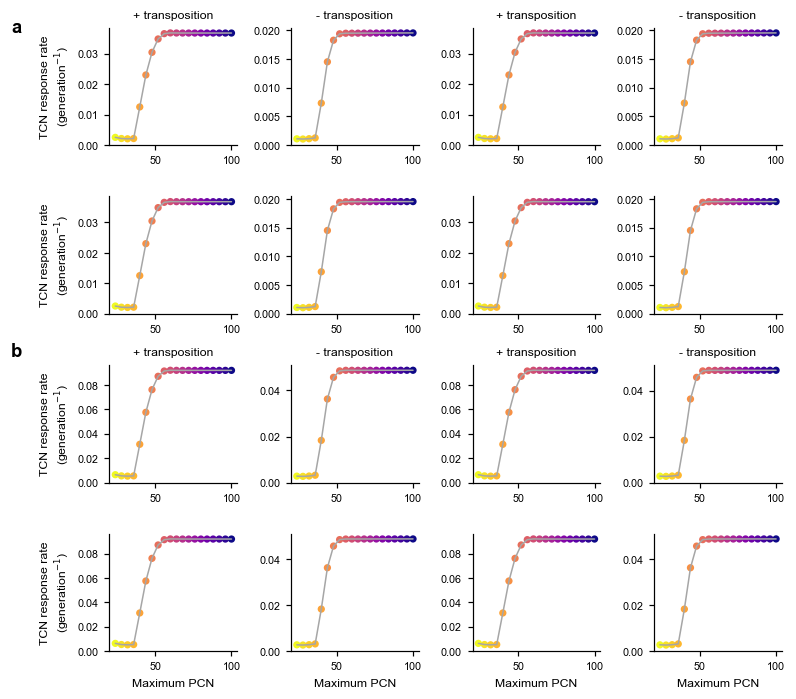

In [2]:
rows=[]
for setting,(family,mean,sd) in SETTINGS.items():
    for max_pcn in PCN_CAPACITY_GRID:
        configs={c.condition:c for c in standard_configurations(int(max_pcn))}
        init=normal_initial_state(int(max_pcn),mean_fraction_of_pcn=mean,sd_fraction_of_pcn=sd)
        for condition in CONDITIONS:
            r=evaluate_configuration(int(max_pcn),configs[condition],initial_state=init.copy())
            r.update({"initialization":setting,"family":family,"mean_fraction":mean,"sd_fraction":sd})
            rows.append(r)
results=pd.DataFrame(rows)

blocks=[("loss","loss_rate",[(0.90,0.05),(0.90,0.10),(0.70,0.05),(0.70,0.10)]),
        ("gain","gain_rate",[(0.10,0.05),(0.10,0.10),(0.30,0.05),(0.30,0.10)])]
fig,axes=plt.subplots(4,4,figsize=(7.3,6.4))
for bi,(family,metric,pairs) in enumerate(blocks):
    for mean,sd in pairs:
        row=bi*2+(0 if sd==0.05 else 1)
        for ci,condition in enumerate(CONDITIONS):
            col=(0 if mean in (0.90,0.10) else 2)+ci
            ax=axes[row,col]
            d=results[(results.family==family)&(results.mean_fraction==mean)&(results.sd_fraction==sd)&(results.condition==condition)&results.response_valid].sort_values("maximum_PCN")
            ax.plot(d.maximum_PCN,d[metric],color="0.65",lw=1)
            ax.scatter(d.maximum_PCN,d[metric],c=d.maximum_PCN,cmap="plasma_r",s=14)
            ax.set_ylim(bottom=0)
            if row==3: ax.set_xlabel("Maximum PCN")
            if col==0: ax.set_ylabel("TCN response rate\n(generation$^{-1}$)")
            if row in (0,2): ax.set_title("+ transposition" if condition=="transposition on" else "- transposition")
fig.text(0.02,0.95,"a",fontweight="bold",fontsize=12); fig.text(0.02,0.49,"b",fontweight="bold",fontsize=12)
fig.tight_layout(rect=(0.04,0,1,1))
save_figure(fig,"Supplementary_Figure_11_normal_initialization",FIGURE_DIR); plt.show()

export_table(results,"Supplementary_Figure_11_source_data.csv",SOURCE_DIR)
export_table(core_metadata("Supplementary Figure 11"),"Supplementary_Figure_11_run_metadata.csv",SOURCE_DIR)
